# 23. Censored flood frequency

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

Bulletin 17C exists because a gauge record is rarely the whole story. A community
remembers the 1927 flood; a high-water mark on a courthouse wall bounds it; nobody
recorded the ordinary years in between, but everyone agrees nothing came close to the
top of the levee. Guidelines for Determining Flood Flow Frequency (Bulletin 17C,
England et al. 2019) calls these **historical** and **paleoflood** observations, and
fitting them alongside the systematic record is the single largest improvement you can
make to a flood-frequency estimate.

This example shows how to express that information with `analysis_data()` and hand it
to an analysis through a model. It has no upstream counterpart: the USACE-RMC
Numerics-Python-Examples repository has no censored-data example.

## What you'll learn

- Record historical floods known only within a range, and perception thresholds
  covering years with no gauge.
- See how censored observations reweight the plotting positions of the systematic
  record.
- Fit Bulletin 17C with and without that information, and compare the design flows.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import corehydropy as ch

## The systematic record

Forty-eight years of annual peak flows in cubic feet per second, the same gauge record
used in [example 21](../21-flood-frequency/python.ipynb).

In [2]:
peak_flows = [
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000,
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600,
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600,
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600,
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460,
]
n = len(peak_flows)
print(f"n = {n}, max = {max(peak_flows):,} cfs")

n = 48, max = 22,600 cfs


## What we know beyond the gauge

Two large floods predate the gauge. Neither was measured, but both left evidence that
brackets them: the first somewhere between 30,000 and 38,000 cfs, the second between
26,000 and 32,000. That is **interval** data, an observation known only to lie in a
range.

The same historical work established that over the fifty years before the gauge was
installed, exactly those two floods exceeded 25,000 cfs. That is a **perception
threshold**: a statement about the years you did not observe, and the reason those two
floods can be used at all. Without it they are just two large numbers with no record
length to weigh them against.

Indexes are 0-based positions in the record. The systematic record occupies 0 to 47, so
the historical period sits at 48 onward.

In [3]:
historical = {
    "index": [n, n + 1],
    "lower": [30000, 26000],
    "value": [34000, 29000],
    "upper": [38000, 32000],
}

perception = {
    "start_index": n,
    "end_index": n + 49,
    "value": 25000,
    "number_above": 2,
}

flood_data = ch.analysis_data(
    exact=peak_flows,
    interval=historical,
    threshold=perception,
)
flood_data

<AnalysisData 48 exact, 2 interval, 1 threshold>

The frame now describes 98 years, not 48:

In [4]:
summary_censored = ch.analysis_data_summary(flood_data)
summary_plain = ch.analysis_data_summary(ch.analysis_data(peak_flows))
print(
    f"record length: {summary_plain['total_record_length']} years systematic "
    f"-> {summary_censored['total_record_length']} years with the historical period"
)

record length: 48 years systematic -> 98 years with the historical period


## Censoring reweights the systematic record

Plotting positions are where each observation lands on a probability plot. With
censored data they are the Hirsch-Stedinger positions, which account for the years you
did not observe. Adding a fifty-year historical period does not change the
observations, but it does change what each one represents.

In [5]:
order = np.argsort(summary_plain["value"])[::-1][:5]
for i in order:
    print(
        f"{summary_plain['value'][i]:>8,.0f} cfs   "
        f"systematic only {summary_plain['plotting_position'][i]:.6f}   "
        f"with historical {summary_censored['plotting_position'][i]:.6f}"
    )

  22,600 cfs   systematic only 0.020408   with historical 0.060392
  21,900 cfs   systematic only 0.040816   with historical 0.079967
  21,400 cfs   systematic only 0.061224   with historical 0.099542
  20,600 cfs   systematic only 0.081633   with historical 0.119117
  19,200 cfs   systematic only 0.102041   with historical 0.138692


These are exceedance probabilities. With 48 years and nothing else, the largest gauged
peak is the record maximum: a 1-in-49 event. Once the two historical floods are on the
record it is only the third largest in 98 years, and its exceedance probability roughly
triples, from 2% to 6%. Censoring corrects an over-optimistic ranking of the largest
thing you happened to measure -- which is precisely the bias historical information
exists to remove.

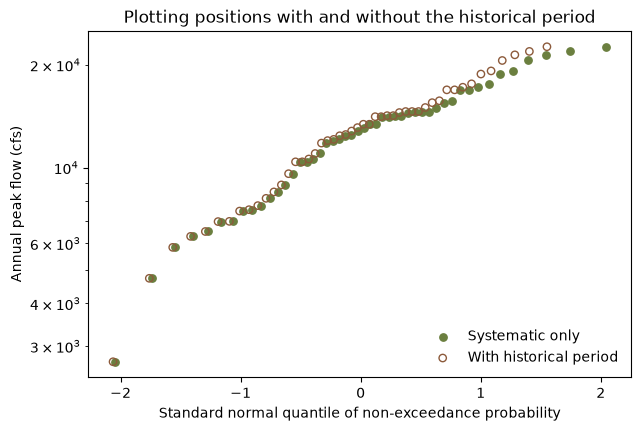

In [6]:
# The standard normal quantile comes from corehydropy itself, no extra dependency.
z = ch.Distribution("Normal", [0, 1]).quantile

# Plotted against the non-exceedance quantile, so rarer events sit to the right.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(z(1 - np.asarray(summary_plain["plotting_position"])), summary_plain["value"],
           s=28, color="#6b7f3f", label="Systematic only")
ax.scatter(z(1 - np.asarray(summary_censored["plotting_position"])), summary_censored["value"],
           s=28, facecolors="none", edgecolors="#8c5a3b", label="With historical period")
ax.set_yscale("log")
ax.set_xlabel("Standard normal quantile of non-exceedance probability")
ax.set_ylabel("Annual peak flow (cfs)")
ax.set_title("Plotting positions with and without the historical period")
ax.legend(frameon=False, loc="lower right")
plt.show()

## Fit Bulletin 17C both ways

`bulletin17c_analysis()` takes a plain sequence for the systematic-only fit. For the
censored fit, wrap the frame in a model and pass that instead. Everything else is
unchanged.

In [7]:
fit_plain = ch.bulletin17c_analysis(peak_flows, output_length=2000, seed=20250811)
fit_censored = ch.bulletin17c_analysis(
    ch.model_bulletin17c(flood_data), output_length=2000, seed=20250811
)

print(f"{'':<18}{'mean (log10)':>14}{'sd (log10)':>13}{'skew':>10}")
for label, fit in (("Systematic only", fit_plain), ("With historical", fit_censored)):
    p = fit["parameters"]
    print(f"{label:<18}{p[0]:>14.4f}{p[1]:>13.4f}{p[2]:>10.4f}")

                    mean (log10)   sd (log10)      skew
Systematic only           4.0674       0.1888   -1.0103
With historical           4.0862       0.2032   -0.6863


The skew moves from -1.01 to -0.69. A strongly negative skew is the log-Pearson III
saying the upper tail is bounded; the two historical floods are direct evidence against
that, and the fit responds.

## Design flows

In [8]:
aeps = [0.5, 0.1, 0.02, 0.01]
eps = list(fit_plain["exceedance_probabilities"])
idx = [eps.index(a) for a in aeps]

print(f"{'Return period':<16}{'AEP':>8}{'Systematic':>13}{'Historical':>13}{'Change':>9}")
for a, i in zip(aeps, idx):
    lo = 10 ** fit_plain["point_estimates"][i]
    hi = 10 ** fit_censored["point_estimates"][i]
    print(f"{'1 in ' + str(round(1 / a)):<16}{a:>8}{lo:>13,.0f}{hi:>13,.0f}"
          f"{100 * (hi / lo - 1):>+8.0f}%")

Return period        AEP   Systematic   Historical   Change
1 in 2               0.5       12,550       12,862      +2%
1 in 10              0.1       19,048       21,240     +12%
1 in 50             0.02       22,279       26,653     +20%
1 in 100            0.01       23,219       28,527     +23%


The 1-in-100 design flow rises by roughly a quarter. The confidence bands widen too,
which is the honest consequence of the interval observations: they add information
about the tail, and they add uncertainty about their own magnitude.

In [9]:
print(f"{'AEP':>7}{'Lower (sys)':>14}{'Upper (sys)':>14}"
      f"{'Lower (hist)':>15}{'Upper (hist)':>15}")
for a, i in zip(aeps, idx):
    print(f"{a:>7}{fit_plain['lower_ci'][i]:>14,.0f}{fit_plain['upper_ci'][i]:>14,.0f}"
          f"{fit_censored['lower_ci'][i]:>15,.0f}{fit_censored['upper_ci'][i]:>15,.0f}")

    AEP   Lower (sys)   Upper (sys)   Lower (hist)   Upper (hist)
    0.5        11,098        14,215         12,050         17,564
    0.1        17,418        21,357         18,431         24,119
   0.02        17,728        26,592         19,976         31,620
   0.01        17,728        28,969         19,976         35,343


## Low outliers

Bulletin 17C also censors from below. Small annual peaks carry little information about
flood risk but drag a log-space fit badly; the Multiple Grubbs-Beck test identifies them
so they can be treated as left-censored rather than dropped or trusted.

In [10]:
print(f"MGBT flags {ch.mgbt_test(peak_flows)} of {n} systematic peaks as low outliers")

MGBT flags 13 of 48 systematic peaks as low outliers


Set `mgbt_low_outliers=True` on the frame to apply it, or `low_outlier_threshold` to
censor below a value you choose. This record is broad enough that the test flags a
sizeable fraction, so this example leaves the low tail alone and censors only from
above; on a record with a few genuine near-zero years, enabling it is standard practice.

## A Bayesian fit over the same frame

Nothing about the frame is specific to Bulletin 17C. Any analysis takes a model, so the
same censored data goes straight into a Bayesian MCMC fit.

In [11]:
bayes = ch.univariate_analysis(
    ch.model_univariate("LogPearsonTypeIII", flood_data),
    sampler="DEMCzs", iterations=400, output_length=2000,
    seed=20250811, thinning_interval=1,
)
print("posterior mode:", ", ".join(f"{v:.4f}" for v in bayes["parameters"]))
print(f"AIC {bayes['aic']:.2f} | BIC {bayes['bic']:.2f} | DIC {bayes['dic']:.2f}")

posterior mode: 4.0824, 0.2047, -0.3914
AIC 996.90 | BIC 1004.65 | DIC 989.24


## Reproduction check

In [12]:
# The pipeline is deterministic (the Bulletin 17C fit is generalized method of moments;
# the Bayesian fit is seeded), so these literals are what this port computes -- and the R
# version asserts exactly the same ones, which is what proves the cross-language
# identity. Both packages run the same compiled core with a bit-exact Mersenne Twister,
# so the match is exact here rather than merely close.
assert summary_plain["total_record_length"] == 48
assert summary_censored["total_record_length"] == 98
assert summary_censored["exact_count"] == 48
assert summary_censored["interval_count"] == 2
assert summary_censored["threshold_count"] == 1

assert max(summary_plain["plotting_position"]) == 0.97959183673469385
assert max(summary_censored["plotting_position"]) == 0.98042482299042066

assert fit_plain["parameters"] == [
    4.0673990603110495, 0.18875601898861979, -1.010270060397249
]
assert fit_censored["parameters"] == [
    4.0862266825545781, 0.2031671188484615, -0.68625874896060901
]

assert fit_plain["point_estimates"][idx[3]] == 4.3658392952709022
assert fit_censored["point_estimates"][idx[3]] == 4.4552510671638359

assert bayes["parameters"] == [
    4.0823735395389731, 0.20467865563373133, -0.39138068432208872
]

# Internal consistency: the historical information raises every design flow and widens
# every confidence band, and both frequency curves increase with return period.
assert all(fit_censored["point_estimates"][i] > fit_plain["point_estimates"][i] for i in idx)
for fit in (fit_plain, fit_censored):
    q = [fit["point_estimates"][i] for i in idx]
    assert all(b > a for a, b in zip(q, q[1:]))
assert all(
    (fit_censored["upper_ci"][i] - fit_censored["lower_ci"][i])
    > (fit_plain["upper_ci"][i] - fit_plain["lower_ci"][i])
    for i in idx
)
print("All reproduction checks passed.")

All reproduction checks passed.


## References

England, J.F., et al. (2019). *Guidelines for Determining Flood Flow Frequency --
Bulletin 17C*. USGS Techniques and Methods 4-B5.

Hirsch, R.M., and Stedinger, J.R. (1987). Plotting positions for historical floods and
their precision. *Water Resources Research* 23(4), 715-727.